In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [5]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (1).csv


In [6]:
df = pd.read_csv("placement_predict_50k Dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             4

In [7]:
print(df.isnull().sum())

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
Salary Package           0
dtype: int64


In [8]:
df = df.drop(columns=["StudentID", "IsAnomaly", "Salary Package"])

print(df.columns)

Index(['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel',
       'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4',
       'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus'],
      dtype='object')


In [9]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [10]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())

   SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  SGPA_Sem5  SGPA_Sem6  \
0       6.02       6.54       6.52       6.00       6.47       5.91   
1       5.84       5.12       5.34       5.18       5.03       4.93   
2       4.91       5.29       5.49       5.73       5.33       5.88   
3       7.67       8.03       8.08       7.64       6.86       7.10   
4       8.14       8.97       8.36       8.55       8.55       8.38   

   SGPA_Sem7  SGPA_Sem8  CGPA  AttendancePercent  ...  Stream_EE  Stream_IT  \
0       6.49       5.50  6.29               73.3  ...      False      False   
1       5.40       5.13  5.23               54.5  ...      False      False   
2       5.82       5.67  5.52               77.6  ...      False       True   
3       7.56       7.39  7.51               68.8  ...      False      False   
4       9.10       8.86  8.65               95.8  ...      False       True   

   Stream_Mechanical  Specialisation_DataScience  Specialisation_Embedded  \
0              False 

In [11]:
X = df.drop(columns=["PlacementStatus"])
y = df["PlacementStatus"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 44)
Testing data: (10000, 44)


In [13]:
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.8912

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      3422
           1       0.89      0.96      0.92      6578

    accuracy                           0.89     10000
   macro avg       0.89      0.86      0.87     10000
weighted avg       0.89      0.89      0.89     10000



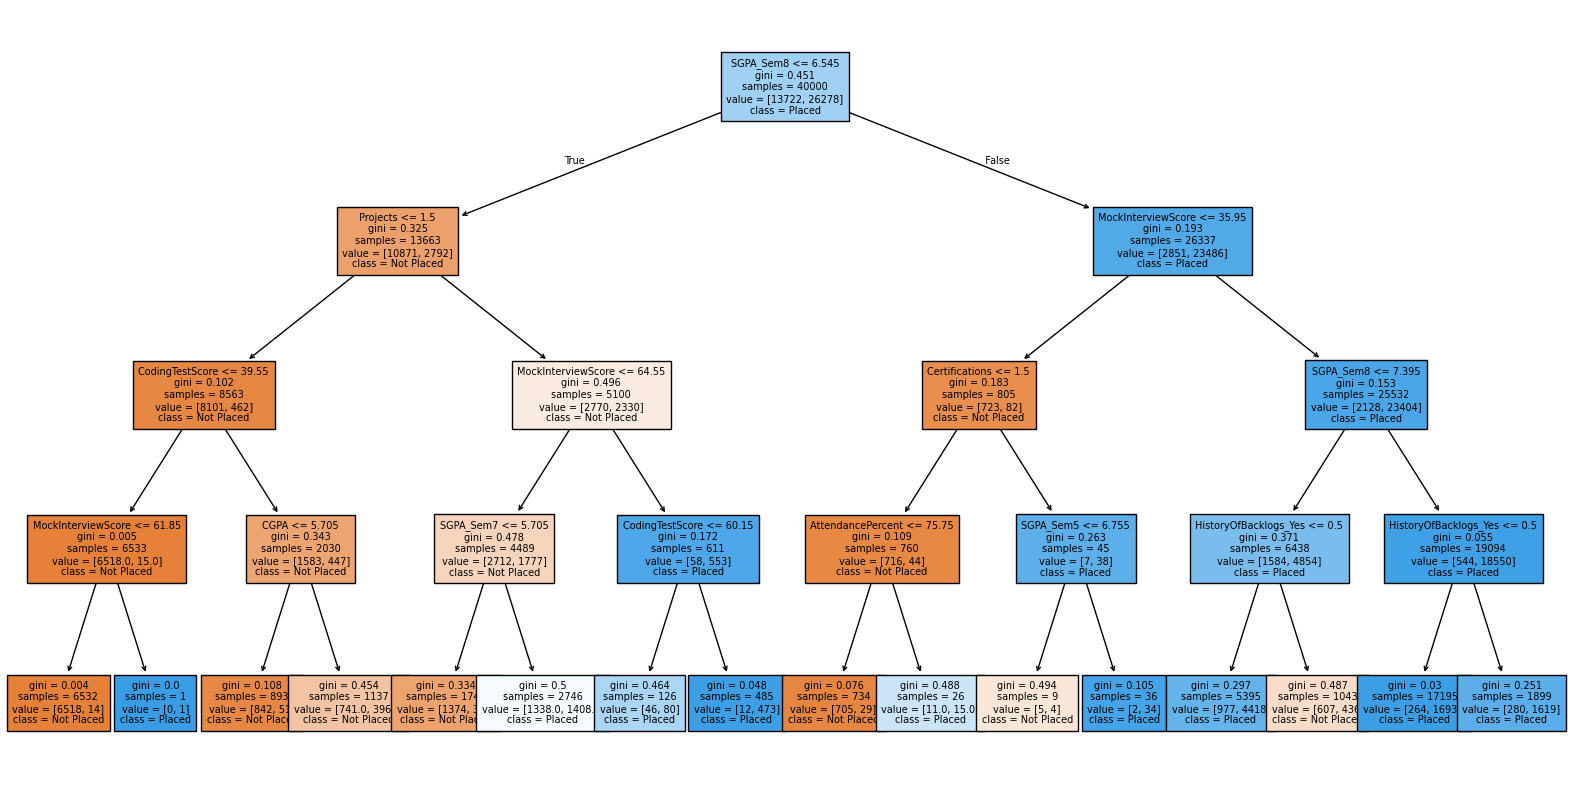

In [14]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=7
)

plt.show()

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [16]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nOOB Score:",
      rf.oob_score_)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9187

OOB Score: 0.919025

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      3422
           1       0.93      0.95      0.94      6578

    accuracy                           0.92     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [17]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

print("Feature Importance:")
print(importance.sort_values(ascending=False))

Feature Importance:
SGPA_Sem8                     0.102532
SGPA_Sem7                     0.092925
SGPA_Sem6                     0.080226
MockInterviewScore            0.068671
CGPA_Tier_Low                 0.058461
SGPA_Sem5                     0.058220
CGPA                          0.053757
SGPA_Sem3                     0.049362
CodingTestScore               0.047835
SGPA_Sem4                     0.046458
SoftSkillsRating              0.044840
SGPA_Sem1                     0.041956
SGPA_Sem2                     0.035510
Projects                      0.034968
Internships                   0.031707
AptitudeTestScore             0.030709
AttendancePercent             0.024144
HistoryOfBacklogs_Yes         0.022442
Certifications                0.017501
Workshops                     0.008336
Publications                  0.004853
CollegeTier_Tier3             0.003352
ExtraCurricular               0.002735
CollegeTier_Tier2             0.002550
Gender_Male                   0.002480
Hoste

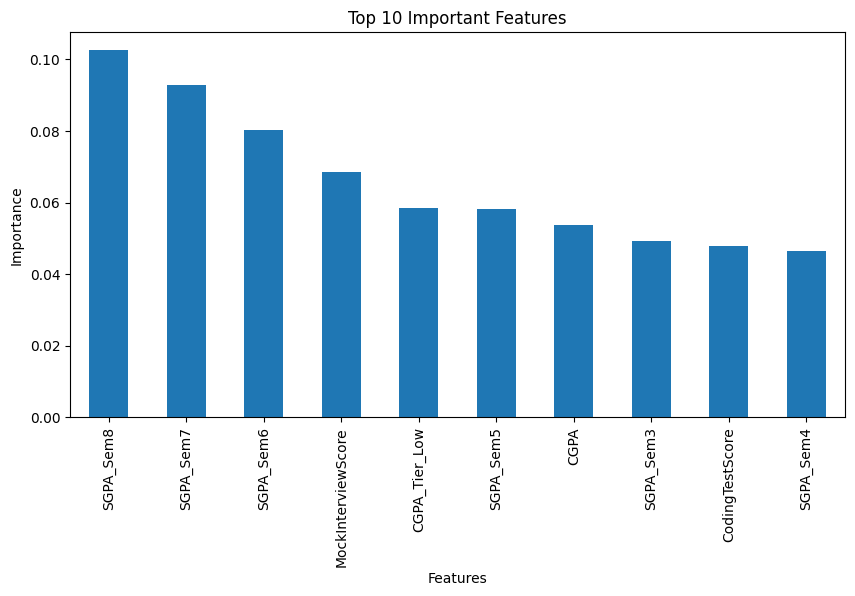

In [18]:
importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [19]:
dt_accuracy = accuracy_score(y_test, dt.predict(X_test))
rf_accuracy = accuracy_score(y_test, rf.predict(X_test))

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest OOB Score:", rf.oob_score_)

Decision Tree Accuracy: 0.8912
Random Forest Accuracy: 0.9187
Random Forest OOB Score: 0.919025
